# Data Statistics 
* Summarizing data. 
* Plotting data.
* Confidence intervals.
* Statistical tests.

In this notebook, we download a dataset with data about customers. Then, we calculate statistical measures and plot distributions. Finally, we perform statistical tests. These are important steps to understand our data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import numpy as np

ModuleNotFoundError: No module named 'statsmodels'


## Understanding the Data

### `customer_dbase_sel.csv`:
We will work with IBM SPSS sample dataset with customer data, **`customer_dbase_sel.csv`**, which contains customer-specific data such as age, income, credit card spendings, commute type and time, etc. [Dataset source](http://www-01.ibm.com/support/knowledgecenter/SSLVMB_20.0.0/com.ibm.spss.statistics.help/data_files.htm)

- **custid** e.g. 0648-AIPJSP-UVM (customer id)
- **gender** e.g. Female or Male
- **age** e.g. 26
- **debtinc** e.g. 11.1 (debt to income ratio in %)
- **card** e.g. Visa, Mastercard (type of primary credit card)
- **carditems** e.g. 1, 2, 3 ... (# of primary credit card purchases in the last month)
- **cardspent** e.g 228.27 (amount in \$ spent on the primary credit card last month)
- **commute** e.g. Walk, Car, Bus (commute type)
- **commutetime** e.g. 22 (time in minutes to commute to work)
- **income** e.g. 16.00 (income in thousands \$ per year)
- **edcat** e.g. College degree, Post-undergraduate degree (education level)

## Reading the data in

In [ ]:
df = pd.read_csv('customer_dbase_sel.csv')

# display first 5 rows of the dataset
df.head()

,custid,gender,age,age_cat,debtinc,card,carditems,cardspent,cardtype,creddebt,...,carown,region,ed_cat,ed_years,job_cat,employ_years,emp_cat,retire,annual_income,inc_cat
0,3964-QJWTRG-NPN,Female,20,18-24,11.1,Mastercard,5,81.66,NaN,1.20,...,Own,Zone 1,Some college,15,Managerial and Professional,0,Less than 2,No,31000.0,$25 - $49
1,0648-AIPJSP-UVM,Male,22,18-24,18.6,Visa,5,42.60,Other,1.22,...,Own,Zone 5,College degree,17,Sales and Office,0,Less than 2,No,15000.0,Under $25
2,5195-TLUDJE-HVO,Female,67,>65,9.9,Visa,9,184.22,NaN,0.93,...,Own,Zone 3,High school degree,14,Sales and Office,16,More than 15,No,35000.0,$25 - $49
3,4459-VLPQUH-3OL,Male,23,18-24,5.7,Visa,17,340.99,NaN,0.02,...,Own,Zone 4,Some college,16,Sales and Office,0,Less than 2,No,20000.0,Under $25
4,8158-SMTQFB-CNO,Male,26,25-34,1.7,Discover,8,255.10,Gold,0.21,...,Lease,Zone 2,Some college,16,Sales and Office,1,Less than 2,No,23000.0,Under $25


### Data Exploration

In [ ]:
# Summarize the data
df.describe()

,age,debtinc,carditems,cardspent,creddebt,commutetime,card2items,card2spent,cars,ed_years,employ_years,annual_income
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,4998.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,46.939800,9.957800,10.19920,339.635878,1.874982,25.346739,4.666000,161.331270,2.134200,14.537600,9.740200,5.504060e+04
std,17.703312,6.423173,3.39279,248.382982,3.441425,5.890674,2.482434,146.798035,1.306037,3.294717,9.691062,5.554475e+04
min,18.000000,0.000000,0.00000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,6.000000,0.000000,9.000000e+03
25%,32.000000,5.175000,8.00000,184.860000,0.390000,21.000000,3.000000,67.682500,1.000000,12.000000,2.000000,2.400000e+04
50%,46.000000,8.800000,10.00000,278.655000,0.930000,25.000000,5.000000,125.455000,2.000000,14.000000,7.000000,3.800000e+04
75%,62.000000,13.500000,12.00000,422.402500,2.080000,29.000000,6.000000,208.612500,3.000000,17.000000,15.000000,6.700000e+04
max,79.000000,43.100000,23.00000,3926.410000,109.070000,48.000000,15.000000,2069.250000,8.000000,23.000000,52.000000,1.073000e+06


In [ ]:
# Number of rows and columns in the data
df.shape

(5000, 30)

In [ ]:
# Display column names
df.columns

Index(['custid', 'gender', 'age', 'age_cat', 'debtinc', 'card', 'carditems',
       'cardspent', 'cardtype', 'creddebt', 'commute', 'commutetime', 'card2',
       'card2items', 'card2spent', 'card2type', 'marital', 'homeown',
       'hometype', 'cars', 'carown', 'region', 'ed_cat', 'ed_years', 'job_cat',
       'employ_years', 'emp_cat', 'retire', 'annual_income', 'inc_cat'],
      dtype='object')

### Labeling Data

income > 30000  --> High-income --> 1  
income < 30000  --> Low-income  --> 0

In [ ]:
# To label data into high-income and low-income
df['income_category'] = df['annual_income'].map(lambda x: 1 if x>30000 else 0)
df[['annual_income','income_category']].head()

,annual_income,income_category
0,31000.0,1
1,15000.0,0
2,35000.0,1
3,20000.0,0
4,23000.0,0


## Data Exploration
#### Select 4 data columns for visualizing:

In [ ]:
viz = df[['cardspent','debtinc','carditems','commutetime']]
viz.head()

,cardspent,debtinc,carditems,commutetime
0,81.66,11.1,5,22.0
1,42.60,18.6,5,29.0
2,184.22,9.9,9,24.0
3,340.99,5.7,17,38.0
4,255.10,1.7,8,32.0


#### Compute descriptive statistics for the data:

In [ ]:
viz.describe()

,cardspent,debtinc,carditems,commutetime
count,5000.000000,5000.000000,5000.00000,4998.000000
mean,339.635878,9.957800,10.19920,25.346739
std,248.382982,6.423173,3.39279,5.890674
min,0.000000,0.000000,0.00000,7.000000
25%,184.860000,5.175000,8.00000,21.000000
50%,278.655000,8.800000,10.00000,25.000000
75%,422.402500,13.500000,12.00000,29.000000
max,3926.410000,43.100000,23.00000,48.000000


Drop NaN (Not-a-Number) observations:

In [ ]:
df[['commutetime']].dropna().count()

commutetime    4998
dtype: int64

Print observations with NaN `commutetime`:

In [ ]:
print( df[np.isnan(df["commutetime"])] )

               custid  gender  age age_cat  debtinc      card  carditems  \
965   3622-JHDLVP-V1E  Female   48   35-49      6.5  Discover         12   
2734  0860-BRGALK-LLR  Female   68     >65     17.3     Other          8   

      cardspent  cardtype  creddebt  ...  region          ed_cat ed_years  \
965      261.91  Platinum      2.25  ...  Zone 1  College degree       19   
2734     178.75  Platinum      1.08  ...  Zone 5    Some college       15   

                                    job_cat  employ_years       emp_cat  \
965                                 Service            12      11 to 15   
2734  Operation, Fabrication, General Labor            20  More than 15   

     retire annual_income     inc_cat  income_category  
965      No      121000.0  $75 - $124                1  
2734    Yes       23000.0   Under $25                0  

[2 rows x 31 columns]


#### Visualize data:

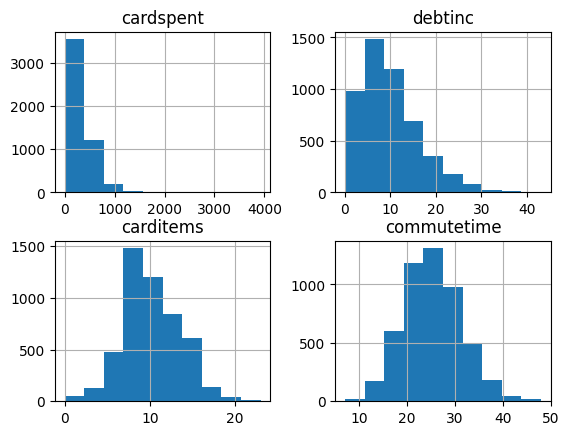

In [ ]:
viz.hist()
plt.show()

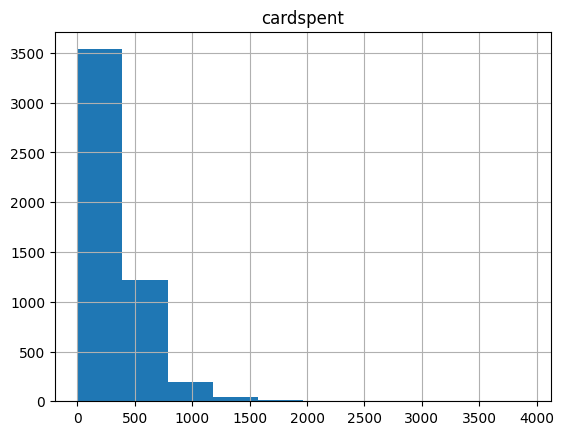

In [ ]:
df[['cardspent']].hist()
plt.show()

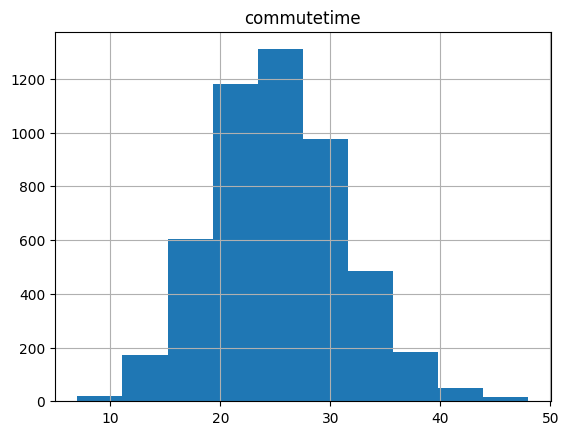

In [ ]:
df[['commutetime']].hist()
plt.show()

## Confidence Intervals

For computing confidence intervals and performing simple statistical tests, we will use the `stats` sub-module of `scipy`:

In [ ]:
from scipy import stats

Confidence intervals tell us how close we think the mean is to the true value, with a certain level of confidence.

We compute mean `mu`, standard deviation `sigma` and the number of observations `N` in our sample of the debt-to-income ratio:

In [ ]:
mu, sigma = np.mean(df[['debtinc']]), np.std(df[['debtinc']])
print ("mean = %G, st. dev = %g" % (mu, sigma))


mean = 9.9578, st. dev = 6.42253


c:\Users\XGWang\miniconda3\envs\'python10'\lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
C:\Users\XGWang\AppData\Local\Temp\ipykernel_18460\1117144253.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print ("mean = %G, st. dev = %g" % (mu, sigma))


In [ ]:
N = len(df[['debtinc']])
N

5000

The 95% confidence interval for the mean of `N` draws from a Normal distribution with mean `mu` and standard deviation `sigma` is

In [ ]:
conf_int = stats.norm.interval( 0.95, loc = mu, scale = sigma/np.sqrt(N) )
conf_int

(array([9.7797798]), array([10.1358202]))

In [ ]:
print ("95%% confidence interval for the mean of debt to income ratio = [%g %g]" % (conf_int[0], conf_int[1]))

95% confidence interval for the mean of debt to income ratio = [9.77978 10.1358]


C:\Users\XGWang\AppData\Local\Temp\ipykernel_18460\3910731290.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ("95%% confidence interval for the mean of debt to income ratio = [%g %g]" % (conf_int[0], conf_int[1]))


In [ ]:
type(conf_int)

tuple

## Statistical Tests

Select columns by name:

In [ ]:
adf=df[['gender','cardspent','debtinc']]
print(adf['gender'])

0       Female
1         Male
2       Female
3         Male
4         Male
         ...  
4995      Male
4996      Male
4997    Female
4998    Female
4999    Female
Name: gender, Length: 5000, dtype: object


Compute means for `cardspent` and `debtinc` for the male and female populations:

In [ ]:
gender_data = adf.groupby('gender')
print (gender_data.mean())

         cardspent   debtinc
gender                      
Female  323.343489  9.985221
Male    356.606840  9.929236


Compute mean for `cardspent` for female population only:

In [ ]:
adf[adf['gender'] == 'Female']['cardspent'].mean()

np.float64(323.3434888279106)

We have seen above that the mean `cardspent` and `debtinc` in the male and female populations were different. To test if this is significant, we do a 2-sample t-test with `scipy.stats.ttest_ind()`:

In [ ]:
female_card = adf[adf['gender'] == 'Female']['cardspent']
male_card = adf[adf['gender'] == 'Male']['cardspent']
tc, pc = stats.ttest_ind(female_card, male_card)
print ("t-test: t = %g  p = %g" % (tc, pc))

t-test: t = -4.74396  p = 2.15418e-06


In the case of amount spent on primary credit card, we conclude that men tend to charge more on their primary card (`p-value = 2e-6 < 0.05`, statistically significant).

In [ ]:
female_debt = adf[adf['gender'] == 'Female']['debtinc']
male_debt   = adf[adf['gender'] == 'Male']['debtinc']
td, pd      = stats.ttest_ind(female_debt, male_debt)
print ("t-test: t = %g  p = %g" % (td, pd))

t-test: t = 0.308069  p = 0.758043


In the case of debt-to-income ratio, we conclude that there is no significant difference between men and women (`p-value = 0.758 > 0.05`, not statistically significant).

## Plot Data

### Plot statistical measures for amounts spent on primary credit card

#### Use `boxplot` to compare medians, 25% and 75% percentiles, 12.5% and 87.5% percentiles:

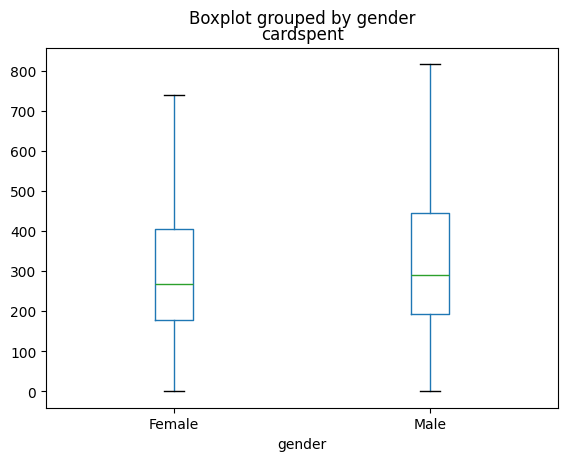

In [ ]:
adf.boxplot(column='cardspent', by='gender', grid=False, showfliers=False)
plt.show()

#### Plot observations with `boxplot`:

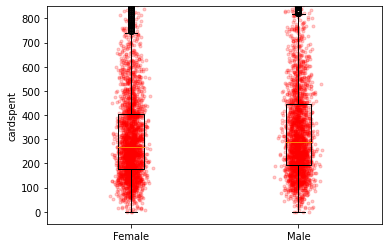

In [ ]:
gend = list(['Female', 'Male'])
for i in [1,2]:
    y = adf.cardspent[adf.gender==gend[i-1]].dropna()        
    # Add some random "jitter" to the x-axis
    x = np.random.normal(i, 0.04, size=len(y))
    plt.plot(x, y, 'r.', alpha=0.2)
plt.boxplot([female_card,male_card],labels=gend)
plt.ylabel("cardspent")
plt.ylim((-50,850))    
plt.show()

### Plot age vs. income data to find some interesting relationships.

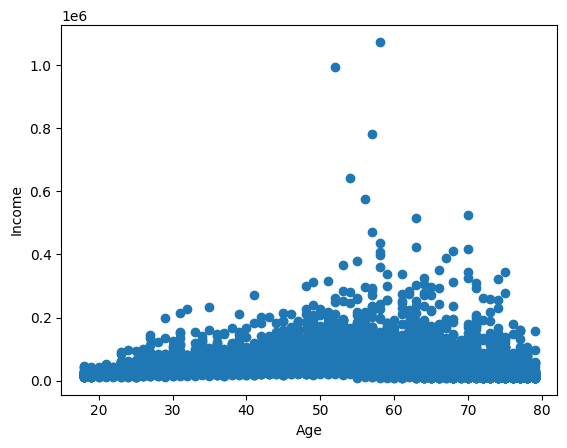

In [ ]:
plt.scatter(df.age, df.annual_income)
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

## Housing Data Example
Here we will generate a model for predicting the sale price of houses, given information about the house features. To train this model we will be using housing data from the USA.

### However, we need to pre-process the data to get good results...

In [ ]:
import seaborn as sns
import pandas as
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [ ]:
# Load data
housingDF = pd.read_csv('USA_housing.csv')
housingDF.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
print(housingDF.columns.values)
print(housingDF.shape)

['Avg. Area Income' 'Avg. Area House Age' 'Avg. Area Number of Rooms'
 'Avg. Area Number of Bedrooms' 'Area Population' 'Price' 'Address']
(5000, 7)


There are 5000 **observations**, 6 **features** and 1 **target** variable.

We can also get more information from the dataframe by using pandas *info()* and *describe()* functions.

In [ ]:
housingDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [ ]:
housingDF.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


From the above, we can discren that there is no missing data (i.e., no null elements in any columns). We can also see some basic statistics about the dataframe. For example, the lowest selling price of the houses in the dataframe is $\$$15,938.66, and the highest price is $\$$2,469,066.

## Data Exploration
Now, let's do some data exploration of our data!

### pairplot
A pairplot plots pairwise relationships between the variables. The diagonal plots show the univariate distribution of the data.

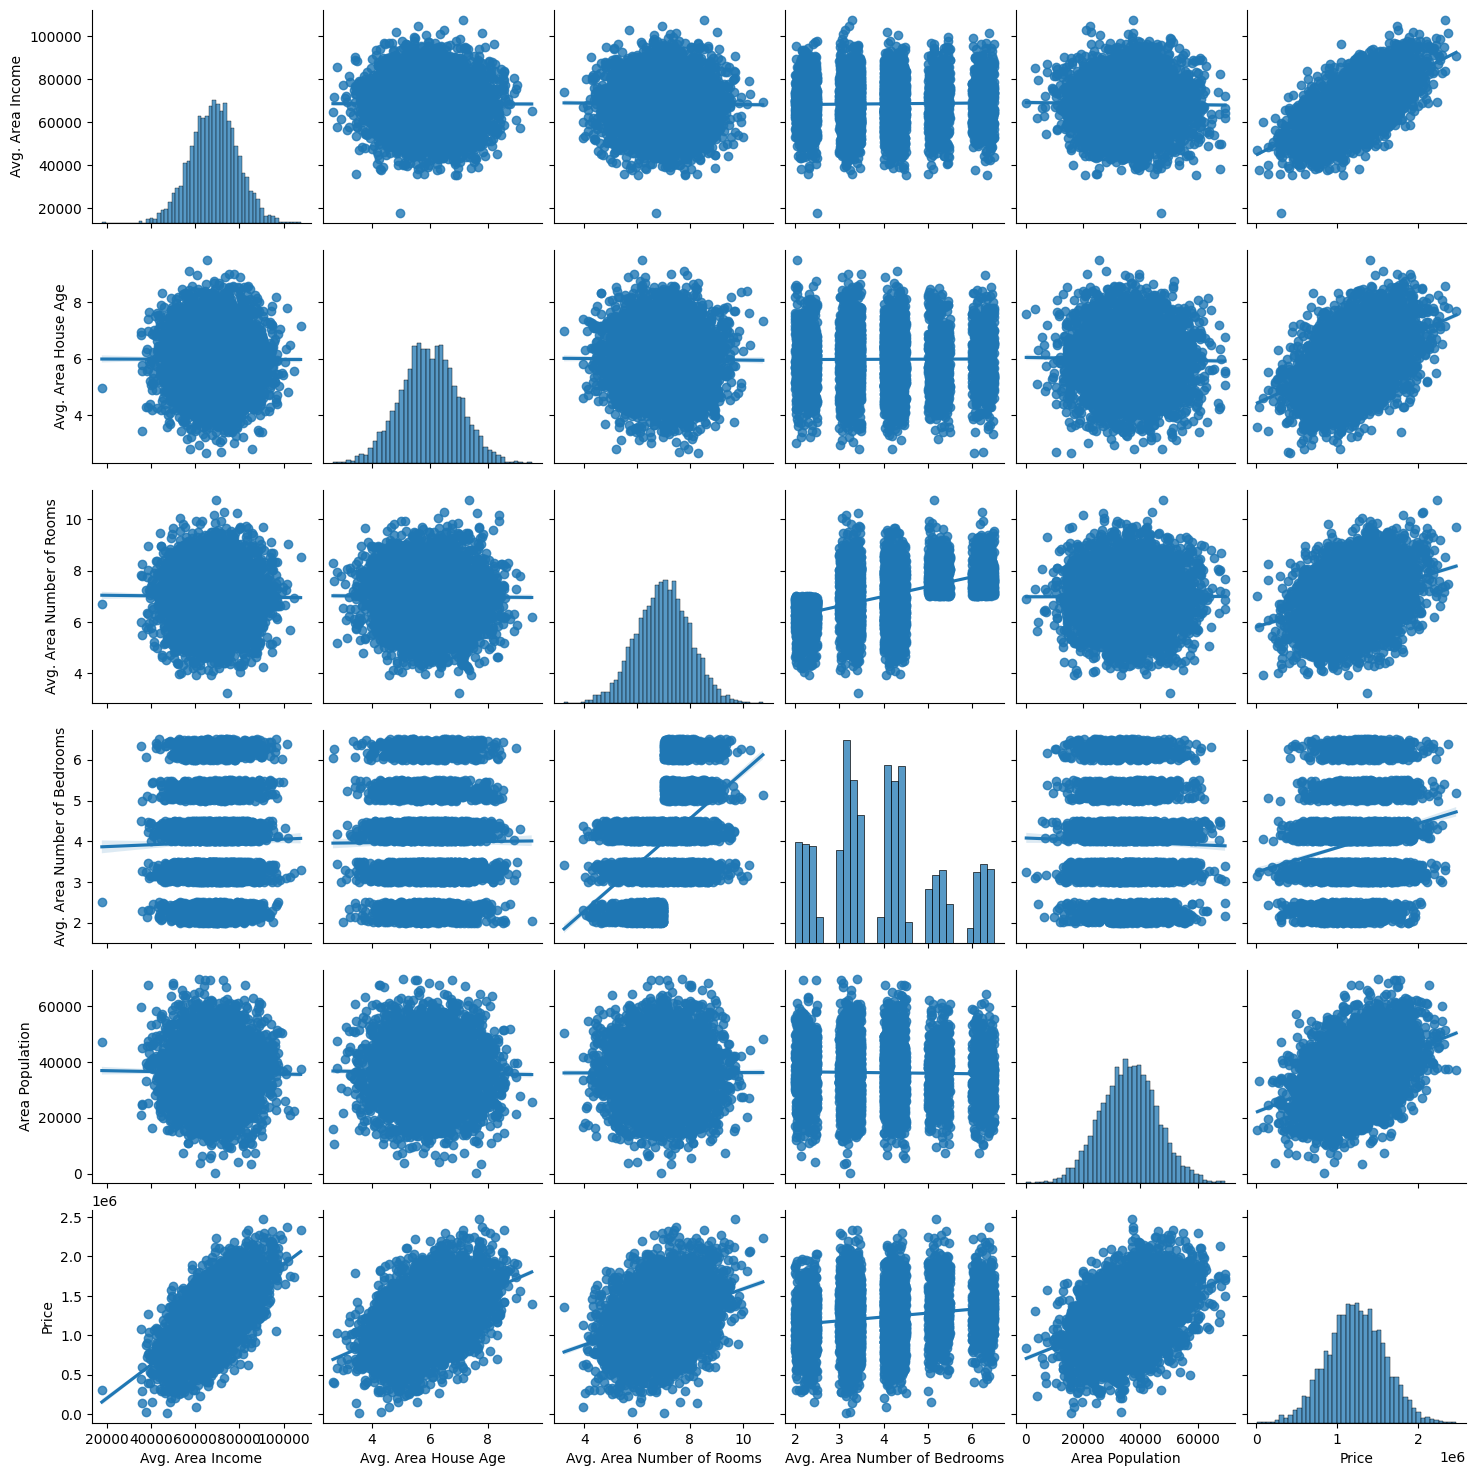

In [ ]:
sns.pairplot(housingDF, kind='reg')

From here, we can see that the average area income has the strongest linear relationship with the price of all the features. We can also see that several of the features and the target variable have normal distributions.

### distplot
We can get the distribution for only one variable by using the seaborn distplot function. Let's look at the distribution of the target variable, price.

C:\Users\XGWang\AppData\Local\Temp\ipykernel_18460\891058084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(housingDF.Price)


<Axes: xlabel='Price', ylabel='Density'>

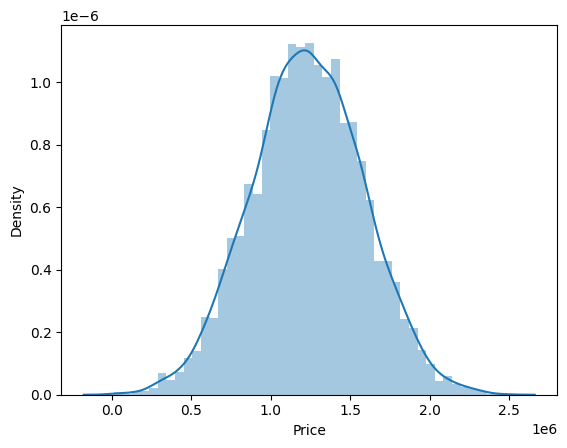

In [ ]:
sns.distplot(housingDF.Price)

As seen above, this plot has a fairly uniform distribution with a mean at around 1.2 million.

### heatmap
We can also look at the correlation between the features and the target variable using seaborn's heatmap function.

We can mask the upper right triangle as they are identical to the lower left triangle. The diagonal also is irrelevant as its the correlation of a feature with itself.

<Axes: >

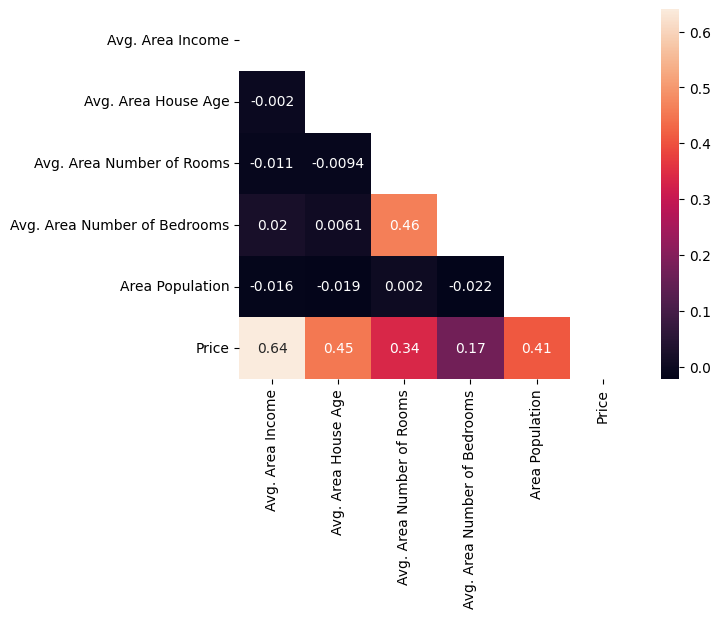

In [ ]:
mask = np.zeros_like(housingDF.iloc[:, 0:-1].corr()*-1)
mask[np.triu_indices_from(mask)] = True

#fig,ax = plt.subplots(figsize=(12,12))
sns.heatmap(housingDF.iloc[:, 0:-1].corr(), mask=mask, annot=True)

As expected, average area income has the highest positive correlation with the target variable. Average number of bedrooms has the lowest positive correlation. None of the features are negatively correlated with the target variable. 

## Data Cleaning
Now let's clean the data a bit. As mentioned before, there is no missing data. We can verify this by plotting a heatmap of the nulls in the dataset.

<Axes: >

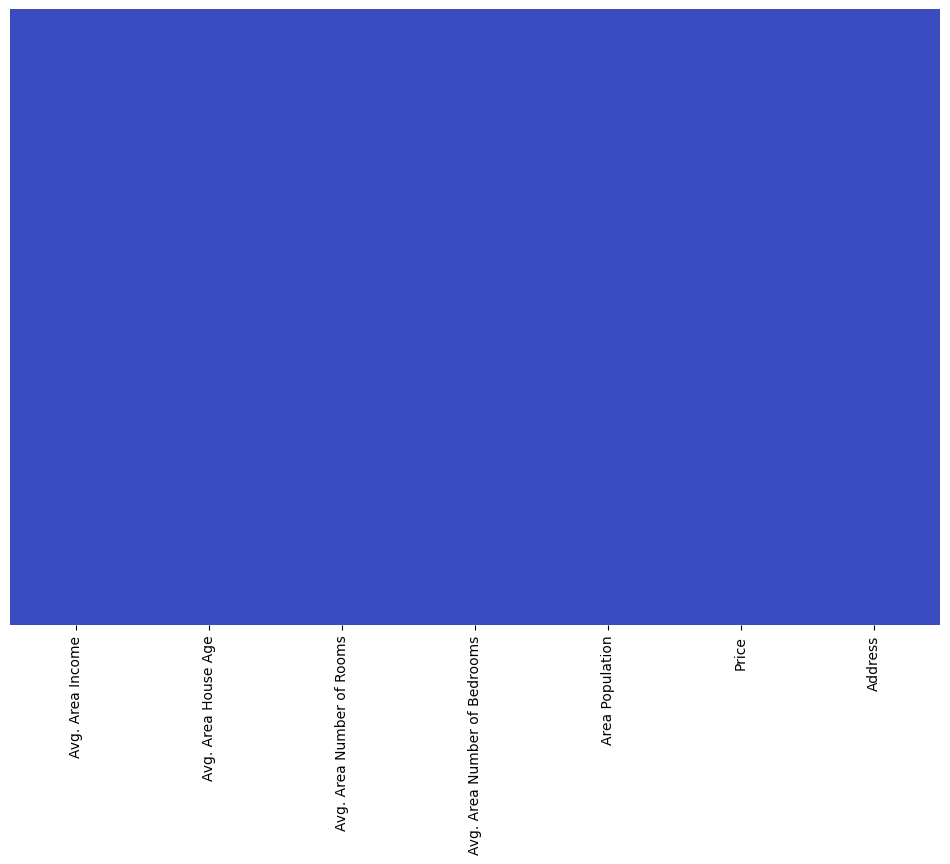

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(housingDF.isnull(), cmap='coolwarm', yticklabels=False, cbar=False, ax=ax)

As expected, there are no red lines indicating NaNs in the dataset.

### Address column
The address column is in a text format so it cannot be fed into a scikit-learn model. This feature could be parsed to create new target variables, such as the type of street, if its a PO box, etc. For this example we will just drop the column and see how the model performs given the remaining features.

In [ ]:
housingDF['Address'].head()
# Drop Address column
housingDF.drop('Address',axis=1,inplace=True)

Let's do a simple linear regression:

$y = \beta_0 + \beta_1x_1 + ... + \beta_nx_n$

Each $x$ represents a different predictor/feature, and each predictor has its own coefficient. In our case:

$y = \beta_0 + \beta_1 \times avgAreaIncome + \beta_2 \times avgAreaHouseAge + \beta_3 \times avgAreaNumOfRooms + \beta_4 \times avgAreaNumOfBedrooms$

Let's use Statsmodels to estimate these coefficients:

In [ ]:
import statsmodels.formula.api as sf

In [ ]:
# create a model with all the features

# Rename the columns since ols doesn't take spaces
tempDF = housingDF.rename(index=str,columns={
        "Avg. Area Income": "avgAreaIncome",
        "Avg. Area House Age": "avgAreaHouseAge",
        "Avg. Area Number of Rooms" : "avgAreaNumOfRooms",
        "Avg. Area Number of Bedrooms": "avgAreaNumOfBedrooms",
        "Area Population": "areaPopulation"
    })

multi_model = sf.ols(formula='Price ~ avgAreaIncome + avgAreaHouseAge + avgAreaNumOfRooms + avgAreaNumOfBedrooms', data=tempDF)
fitted_multi_model = multi_model.fit()

# print the coefficients
print(fitted_multi_model.params)

Intercept              -2.057439e+06
avgAreaIncome           2.135808e+01
avgAreaHouseAge         1.628283e+05
avgAreaNumOfRooms       1.229039e+05
avgAreaNumOfBedrooms   -1.853639e+03
dtype: float64


How do we interpret the coefficients? For a given amount of avg. area house age, avg. area number of rooms, and avg. area number of bedrooms, a **unit** ($\$$1 USD) in avg. area income is associated with an **increase in housing price by ~$\$$21.36 USD.

Other information is available in the model summary output:

In [ ]:
# print a summary of the fitted model
fitted_multi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Price   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     3476.
Date:                Tue, 04 Mar 2025   Prob (F-statistic):               0.00
Time:                        02:25:26   Log-Likelihood:                -67640.
No. Observations:                5000   AIC:                         1.353e+05
Df Residuals:                    4995   BIC:                         1.353e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -2.057e+06   2.92e+04    -70.511      0.000   -2.11e+06      -2e+06
avgAreaIncome           21.3581      0.241     88.579      0.000      20.885      21.831
avgAreaHouseAge       1.628e+05   2591.095     62.842      0.000    1.58e+05    1.68e+05
avgAreaNumOfRooms     1.229e+05   2881.688     42.650      0.000    1.17e+05    1.29e+05
avgAreaNumOfBedrooms -1853.6388   2348.860     -0.789      0.430   -6458.435    2751.157
==============================================================================
Omnibus:                        0.962   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.618   Jarque-Bera (JB):                0.909
Skew:                           0.024   Prob(JB):                        0.635
Kurtosis:                       3.045   Cond. No.                     7.91e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.91e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

* avg area income, avg area house age, and avg area number of rooms have significant **p-values**, whereas avg. area number of bedrooms does not. Thus we reject the former (that there is no association between those features and house Price), and fail to reject the null hypothesis for avg. area number of bedrooms.
* avg area income, avg area house age, and avg area number of rooms are all **positively associated** with housing prices, whereas avg. area number of bedrooms is **negatively associated** with Price.
* This model has a higher **R-squared** (0.736) than the previous model, which means that this model provides a better fit to the data than a model that only includes avg. area income.

## Feature Selection

How do I decide **which features to include** in a linear model? 
- Try different models and check whether the R-squared value goes up when you add new predictors.

What are the **drawbacks** to this approach?
- Linear models rely upon a lot of **assumptions** (such as the predictors/features being independent), and if those assumptions are violated (which they usually are), R-squared are less reliable.
- R-squared is susceptible to **overfitting**, and thus there is no guarantee that a model with a high R-squared value will generalize well to new data. For example:

In [ ]:
# only include avgAreaIncome and avgAreaHouseAge in the model
model1 = sf.ols(formula='Price ~ avgAreaIncome + avgAreaHouseAge', data=tempDF).fit()
print(model1.rsquared)

0.6152185122747899


In [ ]:
# add avgAreaNumOfRooms to the model
model2 = sf.ols(formula='Price ~ avgAreaIncome + avgAreaHouseAge + avgAreaNumOfRooms', data=tempDF).fit()
print(model2.rsquared)

0.7356603185073658


**R-squared will always increase as you add more features to the model**, even if they are unrelated to the response. Thus, selecting the model with the highest R-squared is not a reliable approach for choosing the best linear model.

There is alternative to R-squared called **adjusted R-squared** that penalizes model complexity (to control for overfitting), but this approach has its own set of issues.

Is there a better approach to feature selection? **Cross-validation**, which provides a more reliable estimate of out-of-sample error, and thus is better at choosing which model will better **generalize** to out-of-sample data. Cross-validation can be applied to any type of model, not just linear models.